# EDA: `train_team_track.parquet` и `test_team_track.parquet`

Этот ноутбук делает полный EDA по командному треку с особым фокусом на временные закономерности:

- структура данных и базовая валидация;
- распределения `target_2h` и `status_*`;
- временная структура, сезонность, тренды и сдвиги;
- проверка совместимости train/test для корректного прогнозирования.

> Все временные выводы ниже считаются в **UTC** (как в исходных данных).

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

DATA_DIR = Path("Dd2WPGKz")
TRAIN_PATH = DATA_DIR / "train_team_track.parquet"
TEST_PATH = DATA_DIR / "test_team_track.parquet"

assert TRAIN_PATH.exists(), f"Not found: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Not found: {TEST_PATH}"

train = pd.read_parquet(TRAIN_PATH)
test = pd.read_parquet(TEST_PATH)

# Нормализуем timestamp в UTC для корректной temporal-аналитики
train["timestamp"] = pd.to_datetime(train["timestamp"], utc=True)
test["timestamp"] = pd.to_datetime(test["timestamp"], utc=True)

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (4342000, 12)
test shape: (10000, 3)


## 1) Базовая структура и качество данных

In [2]:
print("Train columns:", list(train.columns))
print("Test columns:", list(test.columns))

print("\nDtypes (train):")
print(train.dtypes)
print("\nDtypes (test):")
print(test.dtypes)

print("\nMissing values (train):")
print(train.isna().sum()[train.isna().sum() > 0])
print("\nMissing values (test):")
print(test.isna().sum()[test.isna().sum() > 0])

dup_train = train.duplicated(subset=["route_id", "timestamp"]).sum()
dup_test = test.duplicated(subset=["route_id", "timestamp"]).sum()
print(f"\nDuplicates by (route_id, timestamp): train={dup_train}, test={dup_test}")

Train columns: ['office_from_id', 'route_id', 'timestamp', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'target_2h']
Test columns: ['id', 'route_id', 'timestamp']

Dtypes (train):
office_from_id                  int64
route_id                        int64
timestamp         datetime64[ns, UTC]
status_1                        int64
status_2                        int64
status_3                        int64
status_4                        int64
status_5                        int64
status_6                        int64
status_7                        int64
status_8                        int64
target_2h                     float64
dtype: object

Dtypes (test):
id                         int64
route_id                   int64
timestamp    datetime64[ns, UTC]
dtype: object

Missing values (train):
Series([], dtype: int64)

Missing values (test):
Series([], dtype: int64)

Duplicates by (route_id, timestamp): train=0, test=0


## 2) Временная структура (главный блок)

Проверим диапазоны времени, дискретизацию, покрытие по маршрутам и корректность перехода `train -> test`.

In [3]:
def report_time_range(df: pd.DataFrame, name: str):
    ts = df["timestamp"]
    print(f"{name}: min={ts.min()}, max={ts.max()}, span={ts.max()-ts.min()}")

report_time_range(train, "train")
report_time_range(test, "test")

print("\nTrain->Test gap:", test["timestamp"].min() - train["timestamp"].max())
print("Test starts strictly after train:", test["timestamp"].min() > train["timestamp"].max())

print("\nUnique timestamps:")
print("train:", train["timestamp"].nunique())
print("test:", test["timestamp"].nunique())

print("\nTest timestamps sorted:")
display(pd.Series(sorted(test["timestamp"].unique()), name="timestamp"))

train: min=2025-03-01 00:00:00+00:00, max=2025-05-30 10:30:00+00:00, span=90 days 10:30:00
test: min=2025-05-30 11:00:00+00:00, max=2025-05-30 15:30:00+00:00, span=0 days 04:30:00

Train->Test gap: 0 days 00:30:00
Test starts strictly after train: True

Unique timestamps:
train: 4342
test: 10

Test timestamps sorted:


0   2025-05-30 11:00:00+00:00
1   2025-05-30 11:30:00+00:00
2   2025-05-30 12:00:00+00:00
3   2025-05-30 12:30:00+00:00
4   2025-05-30 13:00:00+00:00
5   2025-05-30 13:30:00+00:00
6   2025-05-30 14:00:00+00:00
7   2025-05-30 14:30:00+00:00
8   2025-05-30 15:00:00+00:00
9   2025-05-30 15:30:00+00:00
Name: timestamp, dtype: datetime64[ns, UTC]

In [4]:
# Глобальные разницы во времени в отсортированном timestamp
for name, df in [("train", train), ("test", test)]:
    diffs = df["timestamp"].sort_values().diff().dropna()
    print(f"\n{name} - top time diffs:")
    print(diffs.value_counts().head(5))

# Шаг внутри маршрута (ожидаем 30 минут)
rng = np.random.default_rng(42)
route_sample = rng.choice(train["route_id"].unique(), size=500, replace=False)
route_steps = []
for rid in route_sample:
    s = train.loc[train["route_id"] == rid, "timestamp"].sort_values()
    if len(s) > 1:
        route_steps.append(s.diff().dropna().median())

route_steps = pd.Series(route_steps)
print("\nMedian of per-route median step:", route_steps.median())
print("Per-route step counts:")
print(route_steps.value_counts().head(10))


train - top time diffs:
timestamp
0 days 00:00:00    4337658
0 days 00:30:00       4341
Name: count, dtype: int64

test - top time diffs:
timestamp
0 days 00:00:00    9990
0 days 00:30:00       9
Name: count, dtype: int64

Median of per-route median step: 0 days 00:30:00
Per-route step counts:
0 days 00:30:00    500
Name: count, dtype: int64


In [5]:
print("Unique IDs:")
print("train route_id:", train["route_id"].nunique())
print("test route_id:", test["route_id"].nunique())
print("train office_from_id:", train["office_from_id"].nunique())
print("test has office_from_id:", "office_from_id" in test.columns)

train_routes = set(train["route_id"].unique())
test_routes = set(test["route_id"].unique())
print("\nRoute overlap:")
print("only train:", len(train_routes - test_routes))
print("only test:", len(test_routes - train_routes))
print("both:", len(train_routes & test_routes))

route_to_office_nunique = train.groupby("route_id")["office_from_id"].nunique()
print("\nRoutes mapped to >1 office in train:", int((route_to_office_nunique > 1).sum()))

rows_per_route_train = train.groupby("route_id").size()
rows_per_route_test = test.groupby("route_id").size()

print("\nRows per route (train):")
print(rows_per_route_train.describe())
print("\nRows per route (test):")
print(rows_per_route_test.describe())

Unique IDs:
train route_id: 1000
test route_id: 1000
train office_from_id: 53
test has office_from_id: False

Route overlap:
only train: 0
only test: 0
both: 1000

Routes mapped to >1 office in train: 0

Rows per route (train):
count    1000.0
mean     4342.0
std         0.0
min      4342.0
25%      4342.0
50%      4342.0
75%      4342.0
max      4342.0
dtype: float64

Rows per route (test):
count    1000.0
mean       10.0
std         0.0
min        10.0
25%        10.0
50%        10.0
75%        10.0
max        10.0
dtype: float64


## 3) Распределения `target_2h` и `status_*`

target_2h describe:
count    4.342000e+06
mean     6.874518e+01
std      6.748811e+01
min      0.000000e+00
50%      4.800000e+01
90%      1.570000e+02
95%      1.960000e+02
99%      2.930000e+02
max      1.517000e+03
Name: target_2h, dtype: float64

Share of zeros in target_2h: 0.048664440350069095


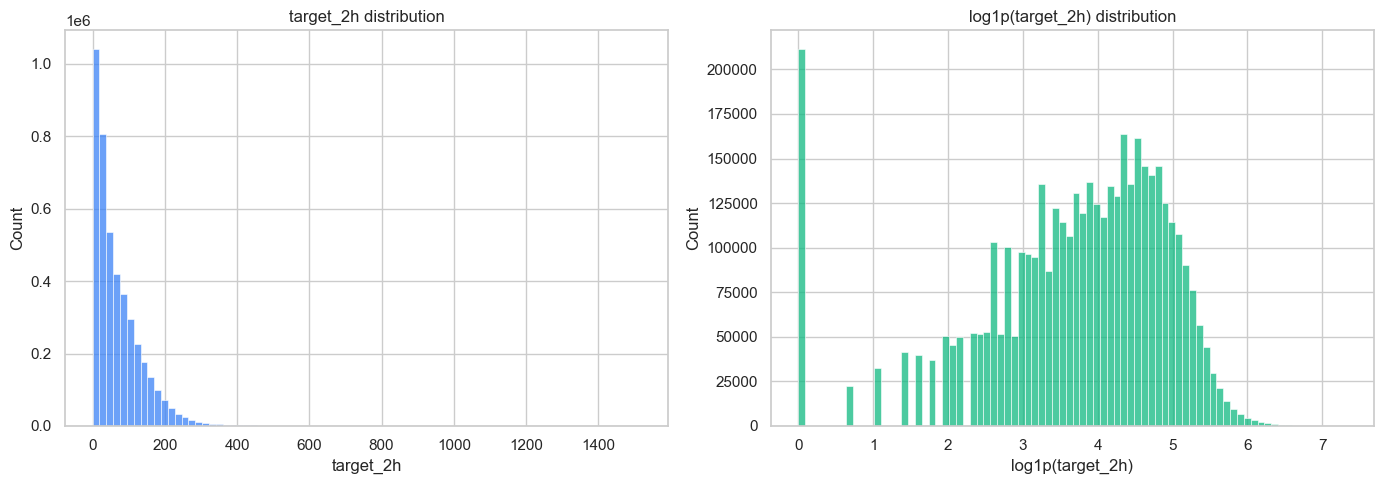

In [5]:
status_cols = [c for c in train.columns if c.startswith("status_")]

print("target_2h describe:")
print(train["target_2h"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print("\nShare of zeros in target_2h:", (train["target_2h"] == 0).mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train["target_2h"], bins=80, ax=axes[0], color="#3b82f6")
axes[0].set_title("target_2h distribution")
axes[0].set_xlabel("target_2h")

sns.histplot(np.log1p(train["target_2h"]), bins=80, ax=axes[1], color="#10b981")
axes[1].set_title("log1p(target_2h) distribution")
axes[1].set_xlabel("log1p(target_2h)")

plt.tight_layout()
plt.show()

,mean,std,min,max
status_7,2243.071239,4913.773645,0.0,76319.0
status_5,1555.774074,2194.728055,0.0,26565.0
status_6,1555.737880,2255.212710,0.0,27702.0
status_1,1310.748731,2501.866251,0.0,36491.0
status_3,1278.569003,2310.502482,0.0,26020.0
status_4,1102.996098,1740.374614,0.0,21170.0
status_8,916.167541,1872.031485,0.0,52039.0
status_2,146.998607,206.666088,0.0,17150.0


Correlation with target_2h:


status_5    0.481257
status_6    0.468166
status_4    0.426476
status_3    0.422644
status_1    0.389965
status_8    0.334934
status_7    0.332776
status_2    0.085748
Name: target_2h, dtype: float64

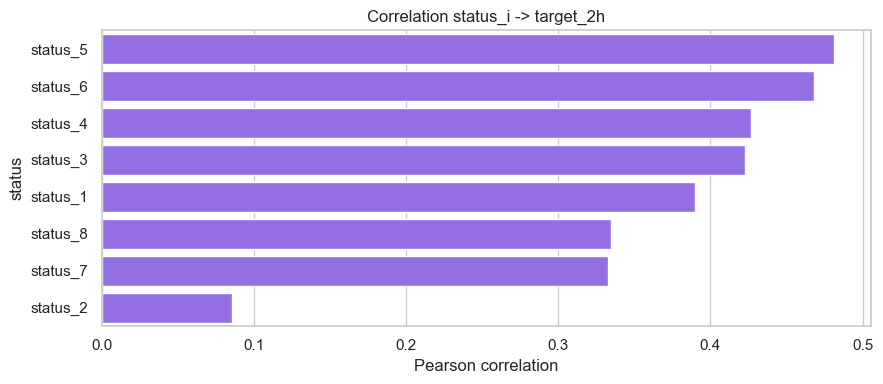

In [6]:
status_stats = train[status_cols].agg(["mean", "std", "min", "max"]).T.sort_values("mean", ascending=False)
display(status_stats)

corr_to_target = train[status_cols + ["target_2h"]].corr(numeric_only=True)["target_2h"].drop("target_2h").sort_values(ascending=False)
print("Correlation with target_2h:")
display(corr_to_target)

plt.figure(figsize=(9, 4))
sns.barplot(x=corr_to_target.values, y=corr_to_target.index, orient="h", color="#8b5cf6")
plt.title("Correlation status_i -> target_2h")
plt.xlabel("Pearson correlation")
plt.ylabel("status")
plt.tight_layout()
plt.show()

## 4) Time patterns: час, день недели, месяц

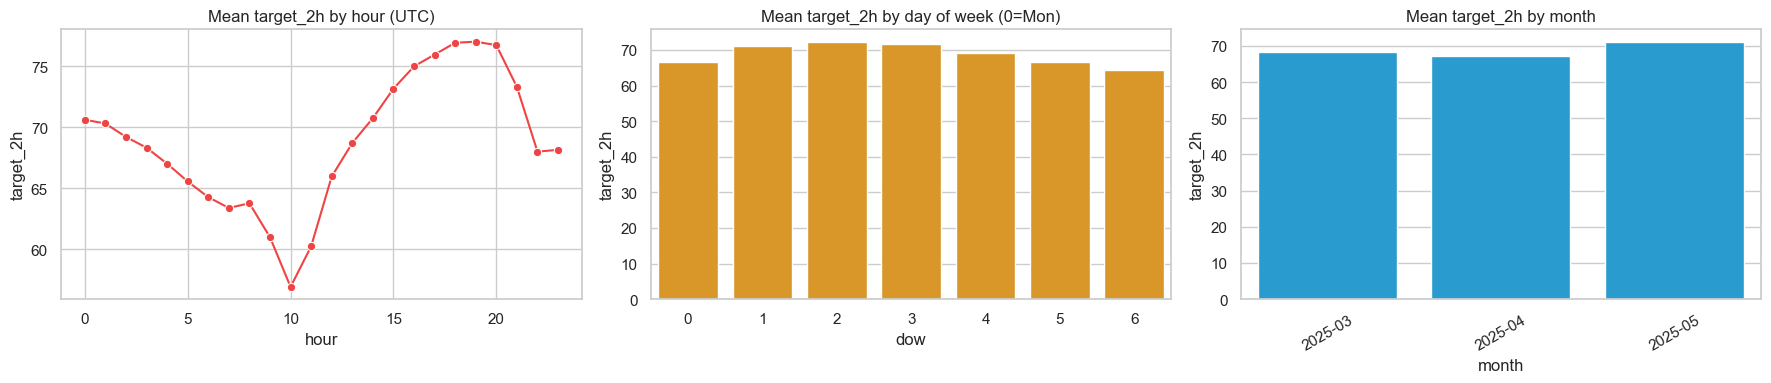

In [7]:
train_ts = train.copy()
train_ts["hour"] = train_ts["timestamp"].dt.hour
train_ts["dow"] = train_ts["timestamp"].dt.dayofweek
train_ts["month"] = train_ts["timestamp"].dt.to_period("M").astype(str)

hourly = train_ts.groupby("hour", as_index=False)["target_2h"].mean()
dow = train_ts.groupby("dow", as_index=False)["target_2h"].mean()
monthly = train_ts.groupby("month", as_index=False)["target_2h"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.lineplot(data=hourly, x="hour", y="target_2h", marker="o", ax=axes[0], color="#ef4444")
axes[0].set_title("Mean target_2h by hour (UTC)")

sns.barplot(data=dow, x="dow", y="target_2h", ax=axes[1], color="#f59e0b")
axes[1].set_title("Mean target_2h by day of week (0=Mon)")

sns.barplot(data=monthly, x="month", y="target_2h", ax=axes[2], color="#0ea5e9")
axes[2].set_title("Mean target_2h by month")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

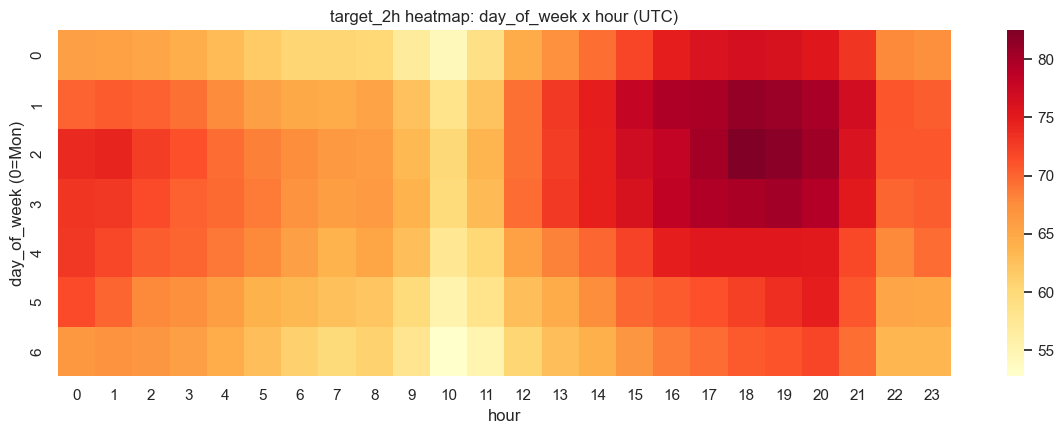

In [8]:
pivot_hour_dow = train_ts.pivot_table(
    values="target_2h", index="dow", columns="hour", aggfunc="mean"
)

plt.figure(figsize=(12, 4.5))
sns.heatmap(pivot_hour_dow, cmap="YlOrRd")
plt.title("target_2h heatmap: day_of_week x hour (UTC)")
plt.xlabel("hour")
plt.ylabel("day_of_week (0=Mon)")
plt.tight_layout()
plt.show()

## 5) Проверка на temporal drift и соответствие test-горизонта

Train start: 2025-03-01 00:00:00+00:00
Train end: 2025-05-30 10:30:00+00:00
Test start: 2025-05-30 11:00:00+00:00
Test end: 2025-05-30 15:30:00+00:00
Gap test_min - train_max: 0 days 00:30:00


,hour,full,last14d
0,0,70.617099,70.748536
1,1,70.310984,70.524929
2,2,69.206385,69.785857
3,3,68.326989,70.073393
4,4,67.014324,68.871571
5,5,65.559044,67.276357
6,6,64.269560,66.701821
7,7,63.381643,66.307750
8,8,63.767797,67.243250
9,9,60.984918,65.926143


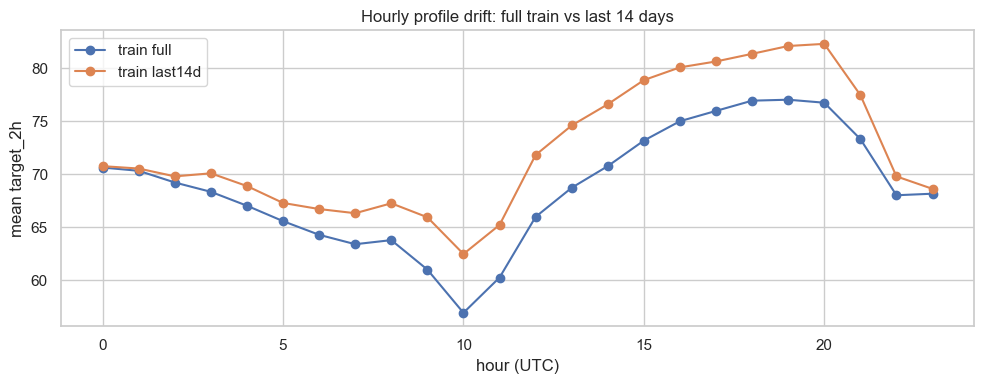

In [9]:
# Сравниваем профиль последних дней train и тестового окна
train_end = train["timestamp"].max()
train_start = train["timestamp"].min()

print("Train start:", train_start)
print("Train end:", train_end)
print("Test start:", test["timestamp"].min())
print("Test end:", test["timestamp"].max())
print("Gap test_min - train_max:", test["timestamp"].min() - train_end)

# Последние 14 дней train
cut_14d = train_end - pd.Timedelta(days=14)
train_last14 = train_ts[train_ts["timestamp"] >= cut_14d].copy()

hourly_full = train_ts.groupby("hour", as_index=False)["target_2h"].mean().rename(columns={"target_2h": "full"})
hourly_last14 = train_last14.groupby("hour", as_index=False)["target_2h"].mean().rename(columns={"target_2h": "last14d"})

cmp_hour = hourly_full.merge(hourly_last14, on="hour", how="outer").sort_values("hour")
display(cmp_hour)

plt.figure(figsize=(10, 4))
plt.plot(cmp_hour["hour"], cmp_hour["full"], marker="o", label="train full")
plt.plot(cmp_hour["hour"], cmp_hour["last14d"], marker="o", label="train last14d")
plt.title("Hourly profile drift: full train vs last 14 days")
plt.xlabel("hour (UTC)")
plt.ylabel("mean target_2h")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Проверяем, сколько истории доступно к каждому timestamp теста
test_points = pd.Series(sorted(test["timestamp"].unique()), name="test_ts")
history_days = (test_points - train_start).dt.total_seconds() / 86400

history_df = pd.DataFrame({
    "test_ts": test_points,
    "history_days_before_point": history_days.round(2)
})
display(history_df)

print("\nВывод:")
print("- для каждой точки теста есть ~90 дней истории train;")
print("- тест находится сразу после train (gap = 30 мин), поэтому нужен forward-only сценарий;")
print("- важны лаги и rolling-признаки по route_id, а также календарные признаки.")

,test_ts,history_days_before_point
0,2025-05-30 11:00:00+00:00,90.46
1,2025-05-30 11:30:00+00:00,90.48
2,2025-05-30 12:00:00+00:00,90.50
3,2025-05-30 12:30:00+00:00,90.52
4,2025-05-30 13:00:00+00:00,90.54
5,2025-05-30 13:30:00+00:00,90.56
6,2025-05-30 14:00:00+00:00,90.58
7,2025-05-30 14:30:00+00:00,90.60
8,2025-05-30 15:00:00+00:00,90.62
9,2025-05-30 15:30:00+00:00,90.65



Вывод:
- для каждой точки теста есть ~90 дней истории train;
- тест находится сразу после train (gap = 30 мин), поэтому нужен forward-only сценарий;
- важны лаги и rolling-признаки по route_id, а также календарные признаки.


## 6) Практические рекомендации по моделированию

На основе EDA:

1. Использовать **time-based split** (rolling/forward validation), не random split.
2. Строить признаки по `route_id`: лаги (`1, 2, 4, 8, 16, 48` шагов) и rolling-окна (`2ч, 6ч, 24ч, 7д`).
3. Добавить календарные признаки: `hour`, `day_of_week`, циклические `sin/cos`-кодировки.
4. Учесть, что в `test` нет `status_*` и `office_from_id`: использовать только стабильные и доступные на inference признаки.
5. Контролировать метрики соревнования `WAPE + |Relative Bias|`, отдельно мониторить bias по маршрутам.

Если нужно, следующим шагом можно прямо в этом ноутбуке добавить блок **feature engineering + baseline model + backtesting**.

## 7) Feature engineering + baseline model + rolling backtest

Ниже блок, который можно запускать как baseline-пайплайн.

Особенность: в `test` нет `status_*`, поэтому baseline строится только на признаках, которые доступны на инференсе:
- календарные признаки из `timestamp`;
- лаги `target_2h` по `route_id`;
- rolling-агрегаты по прошлым значениям `target_2h`.

Такой подход корректно воспроизводит production-условия и не допускает leakage.

In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor

# -------- метрики соревнования --------
def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_true - y_pred).sum() / denom


def relative_bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_pred.sum() - y_true.sum()) / denom


def comp_metric(y_true, y_pred):
    return wape(y_true, y_pred) + relative_bias(y_true, y_pred)


# -------- feature engineering --------
TARGET_COL = "target_2h"
KEY_COLS = ["route_id", "timestamp"]
LAGS = [1, 2, 4, 8, 16, 48]
ROLL_WINDOWS = [4, 12, 48]   # 2ч, 6ч, 24ч при шаге 30 мин


def add_time_features(df):
    out = df.copy()
    out["hour"] = out["timestamp"].dt.hour.astype("int16")
    out["dow"] = out["timestamp"].dt.dayofweek.astype("int16")
    out["is_weekend"] = (out["dow"] >= 5).astype("int8")
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24).astype("float32")
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24).astype("float32")
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7).astype("float32")
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7).astype("float32")
    return out


def add_target_lag_roll_features(df):
    out = df.sort_values(KEY_COLS).copy()
    g = out.groupby("route_id", sort=False)[TARGET_COL]

    for lag in LAGS:
        out[f"y_lag_{lag}"] = g.shift(lag).astype("float32")

    # rolling считаем по прошлому окну (через shift(1), чтобы не заглядывать в текущий y)
    shifted = g.shift(1)
    for w in ROLL_WINDOWS:
        out[f"y_roll_mean_{w}"] = (
            shifted.groupby(out["route_id"], sort=False)
            .rolling(w)
            .mean()
            .reset_index(level=0, drop=True)
            .astype("float32")
        )
        out[f"y_roll_std_{w}"] = (
            shifted.groupby(out["route_id"], sort=False)
            .rolling(w)
            .std()
            .reset_index(level=0, drop=True)
            .fillna(0.0)
            .astype("float32")
        )

    return out


def build_feature_table(df):
    out = add_time_features(df)
    out = add_target_lag_roll_features(out)
    return out


# -------- recursive feature builder для backtest/test --------
def _safe_mean(arr):
    return float(np.mean(arr)) if len(arr) > 0 else np.nan


def _safe_std(arr):
    return float(np.std(arr)) if len(arr) > 1 else 0.0


def make_row_features_from_history(route_id, ts, hist):
    # hist: list прошлых target_2h по маршруту (в хронологическом порядке)
    row = {
        "route_id": route_id,
        "timestamp": ts,
    }

    hour = ts.hour
    dow = ts.dayofweek

    row["hour"] = hour
    row["dow"] = dow
    row["is_weekend"] = int(dow >= 5)
    row["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    row["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    row["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    row["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    for lag in LAGS:
        row[f"y_lag_{lag}"] = hist[-lag] if len(hist) >= lag else np.nan

    for w in ROLL_WINDOWS:
        window = hist[-w:] if len(hist) >= 1 else []
        row[f"y_roll_mean_{w}"] = _safe_mean(window)
        row[f"y_roll_std_{w}"] = _safe_std(window)

    return row

In [11]:
# 1) готовим фичи на train
train_sorted = train.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
feat_df = build_feature_table(train_sorted)

# В recursive backtest/test недоступны status_* и office_from_id,
# поэтому baseline учим только на признаках, которые можем воспроизвести из истории target + timestamp.
blocked_cols = {"office_from_id", TARGET_COL, "timestamp"}
blocked_cols.update(c for c in feat_df.columns if c.startswith("status_"))

feature_cols = [c for c in feat_df.columns if c not in blocked_cols]

# 2) rolling backtest: последние H шагов по каждому маршруту
HORIZON = 10  # как в test: 10 временных точек на маршрут

valid_idx = feat_df.groupby("route_id", sort=False).tail(HORIZON).index
train_idx = feat_df.index.difference(valid_idx)

train_part = feat_df.loc[train_idx].copy()
valid_part = feat_df.loc[valid_idx].copy().sort_values(["timestamp", "route_id"]).reset_index(drop=True)

# для обучения нужны строки без NaN в лаговых/rolling признаках
train_model_df = train_part.dropna(subset=feature_cols + [TARGET_COL]).copy()

X_train = train_model_df[feature_cols]
y_train = train_model_df[TARGET_COL].values

print("Train rows for model:", len(train_model_df))
print("Valid rows for rolling backtest:", len(valid_part))
print("Features:", len(feature_cols))

Train rows for model: 4284000
Valid rows for rolling backtest: 10000
Features: 20


In [12]:
# 3) baseline model
# HistGradientBoosting: быстрый и устойчивый baseline для больших табличных данных
baseline_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.08,
    max_depth=8,
    max_iter=250,
    min_samples_leaf=200,
    random_state=42,
)

baseline_model.fit(X_train, y_train)
print("Model fitted.")

Model fitted.


In [15]:
# 4) recursive rolling backtest на последних H шагах
# История = все значения target до начала valid-окна для каждого маршрута
history_by_route = {}
for rid, grp in train_part.sort_values(["route_id", "timestamp"]).groupby("route_id", sort=False):
    history_by_route[rid] = grp[TARGET_COL].tolist()

valid_routes = sorted(valid_part["route_id"].unique())
valid_timestamps = sorted(valid_part["timestamp"].unique())

pred_rows = []

for ts in valid_timestamps:
    step_rows = []
    step_rids = []

    for rid in valid_routes:
        hist = history_by_route[rid]
        step_rows.append(make_row_features_from_history(rid, ts, hist))
        step_rids.append(rid)

    step_X = pd.DataFrame(step_rows).reindex(columns=feature_cols)
    step_X = step_X.fillna(0.0)
    step_pred = baseline_model.predict(step_X)
    step_pred = np.clip(step_pred, 0.0, None)

    for rid, yhat in zip(step_rids, step_pred):
        history_by_route[rid].append(float(yhat))
        pred_rows.append({"route_id": rid, "timestamp": ts, "y_pred": float(yhat)})

pred_valid = pd.DataFrame(pred_rows)
valid_eval = valid_part[["route_id", "timestamp", TARGET_COL]].merge(
    pred_valid, on=["route_id", "timestamp"], how="left"
)

assert valid_eval["y_pred"].isna().sum() == 0, "Some validation predictions are missing"

y_true = valid_eval[TARGET_COL].values
y_pred = valid_eval["y_pred"].values

wape_val = wape(y_true, y_pred)
rb_val = relative_bias(y_true, y_pred)
score_val = comp_metric(y_true, y_pred)

print("Rolling backtest results:")
print(f"WAPE           : {wape_val:.6f}")
print(f"Relative Bias  : {rb_val:.6f}")
print(f"WAPE + |RB|    : {score_val:.6f}")

Rolling backtest results:
WAPE           : 0.300412
Relative Bias  : 0.065857
WAPE + |RB|    : 0.366270


,step,timestamp,wape,relative_bias,score
0,1,2025-05-30 06:00:00+00:00,0.148707,0.011404,0.160111
1,2,2025-05-30 06:30:00+00:00,0.222944,0.028778,0.251722
2,3,2025-05-30 07:00:00+00:00,0.294166,0.014022,0.308188
3,4,2025-05-30 07:30:00+00:00,0.318688,0.030058,0.348746
4,5,2025-05-30 08:00:00+00:00,0.331461,0.058246,0.389707
5,6,2025-05-30 08:30:00+00:00,0.355932,0.094145,0.450077
6,7,2025-05-30 09:00:00+00:00,0.339846,0.125363,0.465209
7,8,2025-05-30 09:30:00+00:00,0.343900,0.103122,0.447021
8,9,2025-05-30 10:00:00+00:00,0.331242,0.142866,0.474107
9,10,2025-05-30 10:30:00+00:00,0.330881,0.171745,0.502627


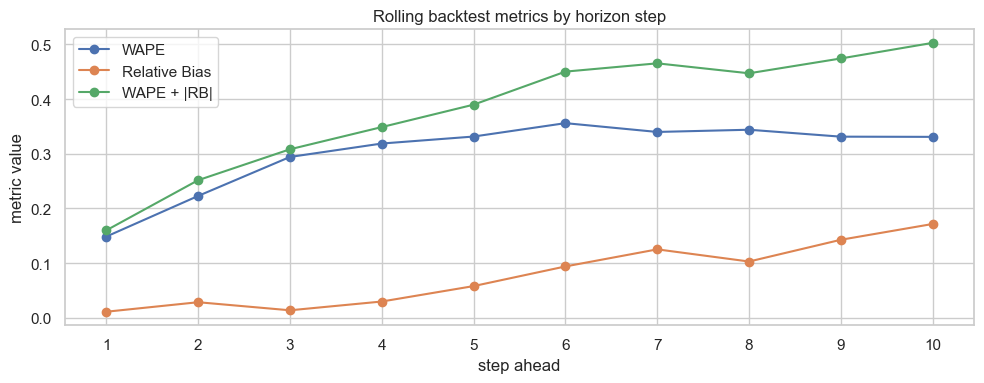

In [16]:
# 5) Метрики по каждому шагу горизонта (диагностика качества)
# Поддержка произвольного порядка запуска ячеек:
# - если valid_eval уже есть, используем его;
# - иначе пробуем hgb_eval (создаётся в блоке сравнения моделей).
valid_eval_local = globals().get("valid_eval")
if valid_eval_local is None:
    valid_eval_local = globals().get("hgb_eval")

if valid_eval_local is None:
    raise RuntimeError(
        "Не найден valid_eval/hgb_eval. Сначала запусти ячейку rolling backtest (где строится valid_eval)."
    )

valid_timestamps_local = sorted(valid_eval_local["timestamp"].unique())

step_metrics = []
for i, ts in enumerate(valid_timestamps_local, start=1):
    tmp = valid_eval_local[valid_eval_local["timestamp"] == ts]
    wt = wape(tmp[TARGET_COL].values, tmp["y_pred"].values)
    rb = relative_bias(tmp[TARGET_COL].values, tmp["y_pred"].values)
    step_metrics.append({
        "step": i,
        "timestamp": ts,
        "wape": wt,
        "relative_bias": rb,
        "score": wt + rb,
    })

step_metrics = pd.DataFrame(step_metrics)
display(step_metrics)

plt.figure(figsize=(10, 4))
plt.plot(step_metrics["step"], step_metrics["wape"], marker="o", label="WAPE")
plt.plot(step_metrics["step"], step_metrics["relative_bias"], marker="o", label="Relative Bias")
plt.plot(step_metrics["step"], step_metrics["score"], marker="o", label="WAPE + |RB|")
plt.title("Rolling backtest metrics by horizon step")
plt.xlabel("step ahead")
plt.ylabel("metric value")
plt.xticks(step_metrics["step"])
plt.legend()
plt.tight_layout()
plt.show()

## 8) (Опционально) Baseline inference на `test` и файл submission

Ниже — рекурсивный инференс на `test` тем же способом, что и в rolling backtest.

> Важно: поскольку `test` не содержит `status_*` и `office_from_id`, baseline использует только временные/лаговые признаки.

In [17]:
# Переобучаем baseline на всем train (без holdout) для финального инференса в test
# Важно: заново фиксируем feature_cols в этой ячейке, чтобы избежать рассинхрона
# при частичном/непоследовательном перезапуске ноутбука.
feat_full = build_feature_table(train_sorted)

blocked_cols_full = {"office_from_id", TARGET_COL, "timestamp"}
blocked_cols_full.update(c for c in feat_full.columns if c.startswith("status_"))
feature_cols = [c for c in feat_full.columns if c not in blocked_cols_full]

full_model_df = feat_full.dropna(subset=feature_cols + [TARGET_COL]).copy()

X_full = full_model_df[feature_cols]
y_full = full_model_df[TARGET_COL].values

final_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.08,
    max_depth=8,
    max_iter=250,
    min_samples_leaf=200,
    random_state=42,
)
final_model.fit(X_full, y_full)

print("Final model fitted on full train.")
print("Rows used:", len(full_model_df))
print("Features used:", len(feature_cols))

Final model fitted on full train.
Rows used: 4294000
Features used: 20


In [18]:
# Рекурсивный прогноз на test
history_test = {}
for rid, grp in train_sorted.groupby("route_id", sort=False):
    history_test[rid] = grp[TARGET_COL].tolist()

test_sorted = test.sort_values(["timestamp", "route_id"]).copy()
test_timestamps = sorted(test_sorted["timestamp"].unique())
routes_test = sorted(test_sorted["route_id"].unique())

# Защита от рассинхрона: используем именно те признаки, на которых обучена модель
final_model_features = list(final_model.feature_names_in_) if hasattr(final_model, "feature_names_in_") else feature_cols

test_preds = []
for ts in test_timestamps:
    rows, rids = [], []
    for rid in routes_test:
        rows.append(make_row_features_from_history(rid, ts, history_test[rid]))
        rids.append(rid)

    X_step = pd.DataFrame(rows).reindex(columns=final_model_features).fillna(0.0)
    yhat = final_model.predict(X_step)
    yhat = np.clip(yhat, 0.0, None)

    for rid, pred in zip(rids, yhat):
        history_test[rid].append(float(pred))
        test_preds.append({"route_id": rid, "timestamp": ts, "y_pred": float(pred)})

pred_test_df = pd.DataFrame(test_preds)
submission = test[["id", "route_id", "timestamp"]].merge(
    pred_test_df, on=["route_id", "timestamp"], how="left"
)[["id", "y_pred"]]

assert submission["y_pred"].isna().sum() == 0, "Missing predictions in submission"
submission.to_csv("submission_baseline_rolling.csv", index=False)

display(submission.head())
print("Saved: submission_baseline_rolling.csv")

,id,y_pred
0,0,102.227071
1,1,81.819911
2,2,68.798996
3,3,40.910570
4,4,38.138411


Saved: submission_baseline_rolling.csv


### Короткий вывод по блоку baseline

- Реализован корректный **rolling backtest** с рекурсивным прогнозом на горизонте `HORIZON=10`.
- Считаются и выводятся все необходимые метрики: `WAPE`, `Relative Bias`, `WAPE + |Relative Bias|`.
- Добавлен production-like инференс на `test` и сохранение `submission_baseline_rolling.csv`.

## 9) Второй baseline (Ridge) + сравнение моделей

Добавляем линейный baseline (`Ridge`) и считаем те же rolling backtest-метрики для честного сравнения с `HistGradientBoostingRegressor`.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def recursive_backtest_predict(model, feature_cols, train_part_df, valid_part_df):
    """
    Рекурсивный прогноз на valid-окне.
    train_part_df: история до valid-окна (с true target)
    valid_part_df: окно валидации (true target используется только для оценки)
    """
    history_by_route = {}
    for rid, grp in train_part_df.sort_values(["route_id", "timestamp"]).groupby("route_id", sort=False):
        history_by_route[rid] = grp[TARGET_COL].tolist()

    valid_routes = sorted(valid_part_df["route_id"].unique())
    valid_timestamps = sorted(valid_part_df["timestamp"].unique())

    pred_rows = []
    for ts in valid_timestamps:
        step_rows = []
        step_rids = []

        for rid in valid_routes:
            hist = history_by_route[rid]
            step_rows.append(make_row_features_from_history(rid, ts, hist))
            step_rids.append(rid)

        step_X = pd.DataFrame(step_rows).reindex(columns=feature_cols).fillna(0.0)
        step_pred = model.predict(step_X)
        step_pred = np.clip(step_pred, 0.0, None)

        for rid, yhat in zip(step_rids, step_pred):
            history_by_route[rid].append(float(yhat))
            pred_rows.append({"route_id": rid, "timestamp": ts, "y_pred": float(yhat)})

    pred_valid_df = pd.DataFrame(pred_rows)
    valid_eval_df = valid_part_df[["route_id", "timestamp", TARGET_COL]].merge(
        pred_valid_df, on=["route_id", "timestamp"], how="left"
    )

    assert valid_eval_df["y_pred"].isna().sum() == 0, "Some predictions are missing in recursive backtest"
    return valid_eval_df


def calc_metrics(valid_eval_df):
    y_true = valid_eval_df[TARGET_COL].values
    y_pred = valid_eval_df["y_pred"].values
    m_wape = wape(y_true, y_pred)
    m_rb = relative_bias(y_true, y_pred)
    m_score = m_wape + m_rb
    return m_wape, m_rb, m_score

In [ ]:
# 1) Модель 1: HistGradientBoosting (уже обучена как baseline_model)
hgb_eval = recursive_backtest_predict(
    model=baseline_model,
    feature_cols=feature_cols,
    train_part_df=train_part,
    valid_part_df=valid_part,
)
hgb_wape, hgb_rb, hgb_score = calc_metrics(hgb_eval)

# 2) Модель 2: Ridge (с масштабированием)
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=2.0, random_state=42)),
])
ridge_model.fit(X_train, y_train)

ridge_eval = recursive_backtest_predict(
    model=ridge_model,
    feature_cols=feature_cols,
    train_part_df=train_part,
    valid_part_df=valid_part,
)
ridge_wape, ridge_rb, ridge_score = calc_metrics(ridge_eval)

print("HGB  :", hgb_wape, hgb_rb, hgb_score)
print("Ridge:", ridge_wape, ridge_rb, ridge_score)

HGB  : 0.30021522332499057 0.0660313242183102 0.36624654754330077
Ridge: 0.3210208325193401 0.10039065536343139 0.4214114878827715


In [ ]:
comparison = pd.DataFrame([
    {
        "model": "HistGradientBoostingRegressor",
        "WAPE": hgb_wape,
        "Relative_Bias": hgb_rb,
        "WAPE_plus_abs_RB": hgb_score,
    },
    {
        "model": "Ridge",
        "WAPE": ridge_wape,
        "Relative_Bias": ridge_rb,
        "WAPE_plus_abs_RB": ridge_score,
    },
]).sort_values("WAPE_plus_abs_RB", ascending=True).reset_index(drop=True)

comparison_style = comparison.style.format({
    "WAPE": "{:.6f}",
    "Relative_Bias": "{:.6f}",
    "WAPE_plus_abs_RB": "{:.6f}",
}).background_gradient(subset=["WAPE_plus_abs_RB"], cmap="YlGn_r")

display(comparison_style)

winner = comparison.iloc[0]["model"]
print(f"Best model by competition metric: {winner}")

,model,WAPE,Relative_Bias,WAPE_plus_abs_RB
0,HistGradientBoostingRegressor,0.300215,0.066031,0.366247
1,Ridge,0.321021,0.100391,0.421411


Best model by competition metric: HistGradientBoostingRegressor


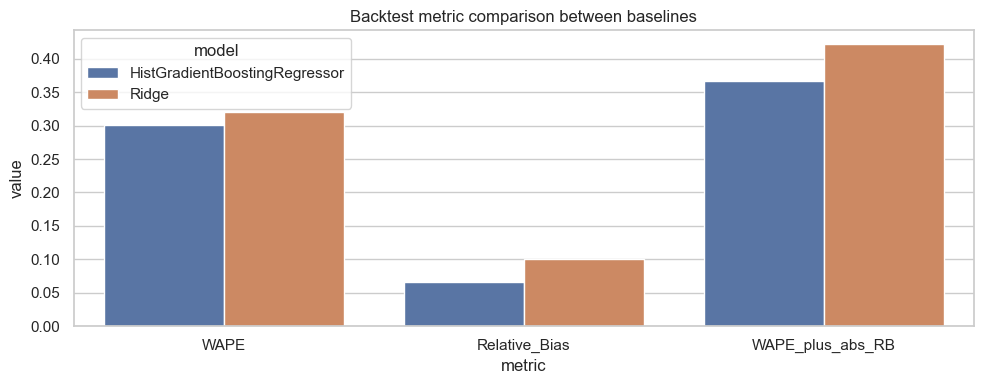

In [ ]:
# Диаграмма сравнения
plot_df = comparison.melt(
    id_vars=["model"],
    value_vars=["WAPE", "Relative_Bias", "WAPE_plus_abs_RB"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="metric", y="value", hue="model")
plt.title("Backtest metric comparison between baselines")
plt.xlabel("metric")
plt.ylabel("value")
plt.tight_layout()
plt.show()

## 10) Третий baseline + mini leaderboard + submissions для всех моделей

Добавляем третий baseline `RandomForestRegressor`, считаем единый leaderboard по 3 моделям на rolling backtest и сохраняем отдельные `submission`-файлы для каждой модели.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Третий baseline
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=16,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train, y_train)

rf_eval = recursive_backtest_predict(
    model=rf_model,
    feature_cols=feature_cols,
    train_part_df=train_part,
    valid_part_df=valid_part,
)
rf_wape, rf_rb, rf_score = calc_metrics(rf_eval)

print("RandomForest:", rf_wape, rf_rb, rf_score)

KeyboardInterrupt: 

In [ ]:
# Mini leaderboard: 3 модели
leaderboard = pd.DataFrame([
    {
        "model": "HistGradientBoostingRegressor",
        "WAPE": hgb_wape,
        "Relative_Bias": hgb_rb,
        "WAPE_plus_abs_RB": hgb_score,
    },
    {
        "model": "Ridge",
        "WAPE": ridge_wape,
        "Relative_Bias": ridge_rb,
        "WAPE_plus_abs_RB": ridge_score,
    },
    {
        "model": "RandomForestRegressor",
        "WAPE": rf_wape,
        "Relative_Bias": rf_rb,
        "WAPE_plus_abs_RB": rf_score,
    },
]).sort_values("WAPE_plus_abs_RB").reset_index(drop=True)

display(
    leaderboard.style.format({
        "WAPE": "{:.6f}",
        "Relative_Bias": "{:.6f}",
        "WAPE_plus_abs_RB": "{:.6f}",
    }).background_gradient(subset=["WAPE_plus_abs_RB"], cmap="YlGn_r")
)

best_model_name = leaderboard.iloc[0]["model"]
print("Best model by backtest:", best_model_name)

plt.figure(figsize=(10, 4))
plot_df = leaderboard.melt(
    id_vars=["model"],
    value_vars=["WAPE", "Relative_Bias", "WAPE_plus_abs_RB"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=plot_df, x="metric", y="value", hue="model")
plt.title("Mini leaderboard: 3 baselines")
plt.tight_layout()
plt.show()

In [ ]:
def recursive_predict_test(model, feature_cols, train_history_df, test_df):
    history_test = {}
    for rid, grp in train_history_df.sort_values(["route_id", "timestamp"]).groupby("route_id", sort=False):
        history_test[rid] = grp[TARGET_COL].tolist()

    # Берем эталон id строго из исходного test и сохраняем его порядок
    base_test = test_df[["id", "route_id", "timestamp"]].copy()
    base_test["timestamp"] = pd.to_datetime(base_test["timestamp"], utc=True)

    assert base_test["id"].isna().sum() == 0, "test id contains NaN"
    assert base_test["id"].nunique() == len(base_test), "test id must be unique"

    test_timestamps = sorted(base_test["timestamp"].unique())
    routes_test = sorted(base_test["route_id"].unique())

    pred_rows = []
    for ts in test_timestamps:
        rows = []
        rids = []
        for rid in routes_test:
            rows.append(make_row_features_from_history(rid, ts, history_test[rid]))
            rids.append(rid)

        X_step = pd.DataFrame(rows).reindex(columns=feature_cols).fillna(0.0)
        yhat = model.predict(X_step)
        yhat = np.clip(yhat, 0.0, None)

        for rid, pred in zip(rids, yhat):
            history_test[rid].append(float(pred))
            pred_rows.append({"route_id": rid, "timestamp": ts, "y_pred": float(pred)})

    pred_test = pd.DataFrame(pred_rows)
    pred_test["timestamp"] = pd.to_datetime(pred_test["timestamp"], utc=True)

    submission_df = base_test.merge(
        pred_test, on=["route_id", "timestamp"], how="left", validate="one_to_one"
    )[["id", "y_pred"]]

    # Финальная гарантия: id в submission полностью совпадают с id из test
    submission_df["id"] = submission_df["id"].astype("int64")
    assert submission_df["id"].tolist() == base_test["id"].astype("int64").tolist(), "id order mismatch"
    assert submission_df["y_pred"].isna().sum() == 0, "Missing predictions in submission"

    return submission_df

In [ ]:
# Переобучение всех 3 моделей на полном train и сохранение submission для каждой
# Повторно фиксируем feature_cols, чтобы не зависеть от порядка запуска
if "feat_full" not in globals():
    feat_full = build_feature_table(train_sorted)

blocked_cols_full = {"office_from_id", TARGET_COL, "timestamp"}
blocked_cols_full.update(c for c in feat_full.columns if c.startswith("status_"))
feature_cols = [c for c in feat_full.columns if c not in blocked_cols_full]

full_model_df = feat_full.dropna(subset=feature_cols + [TARGET_COL]).copy()
X_full = full_model_df[feature_cols]
y_full = full_model_df[TARGET_COL].values

model_zoo = {
    "hgb": HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.08,
        max_depth=8,
        max_iter=250,
        min_samples_leaf=200,
        random_state=42,
    ),
    "ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=2.0, random_state=42)),
    ]),
    "rf": RandomForestRegressor(
        n_estimators=200,
        max_depth=16,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=42,
    ),
}

saved_files = []
for name, model in model_zoo.items():
    print(f"Training full model: {name}")
    model.fit(X_full, y_full)

    model_features = list(model.feature_names_in_) if hasattr(model, "feature_names_in_") else feature_cols

    sub = recursive_predict_test(
        model=model,
        feature_cols=model_features,
        train_history_df=train_sorted,
        test_df=test,
    )
    fname = f"submission_{name}_rolling.csv"
    sub.to_csv(fname, index=False)
    saved_files.append(fname)

print("\nSaved submissions:")
for f in saved_files:
    print("-", f)

# Контроль id для лидерборда
for f in saved_files:
    chk = pd.read_csv(f)
    print(
        f,
        "| rows=", len(chk),
        "| id_nunique=", chk["id"].nunique(),
        "| id_min=", chk["id"].min(),
        "| id_max=", chk["id"].max(),
    )

In [ ]:
# Быстрый просмотр head для всех submission
for f in ["submission_hgb_rolling.csv", "submission_ridge_rolling.csv", "submission_rf_rolling.csv"]:
    print("\n", f)
    display(pd.read_csv(f).head())


## 11) Похожие тренды по складам (`office_from_id`) и группировка складов

Здесь добавляем отдельный EDA-блок по складам.  
Идея:

1. Перейти от `route_id` к `office_from_id` (в train это отображение 1-к-1 уже проверено выше).
2. Построить **типовой временной профиль** целевой переменной для каждого склада.
3. Найти склады с **похожими профилями**.
4. Сгруппировать склады по форме тренда и визуализировать:
   - средний профиль кластера;
   - примеры складов из каждого кластера;
   - пары складов с максимальной корреляцией профилей.

Это полезно для прогноза, потому что позволяет:
- переносить статистики между похожими складами;
- строить cluster-level / office-level признаки;
- использовать отдельные модели по группам похожих складов.


Office profile matrix shape: (53, 336)


,k,silhouette
0,2,0.167616
1,3,0.129081
2,4,0.091984
3,5,0.113901
4,6,0.104693
5,7,0.091539
6,8,0.066490


Best k by silhouette: 2


,office_from_id,trend_cluster
0,2,0
1,4,0
2,5,0
3,8,0
4,9,0
5,14,0
6,15,0
7,18,0
8,20,0
9,26,0


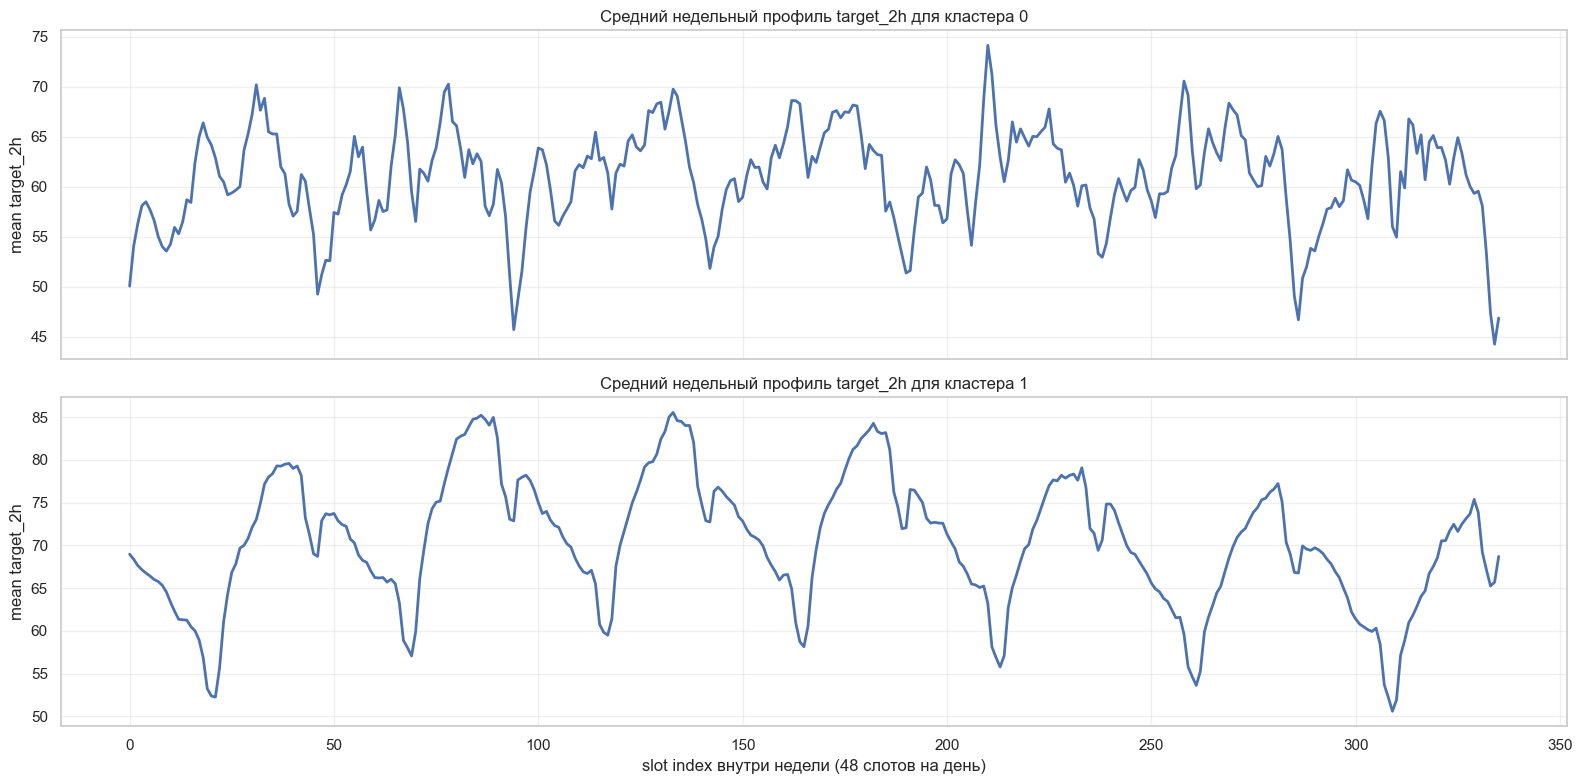

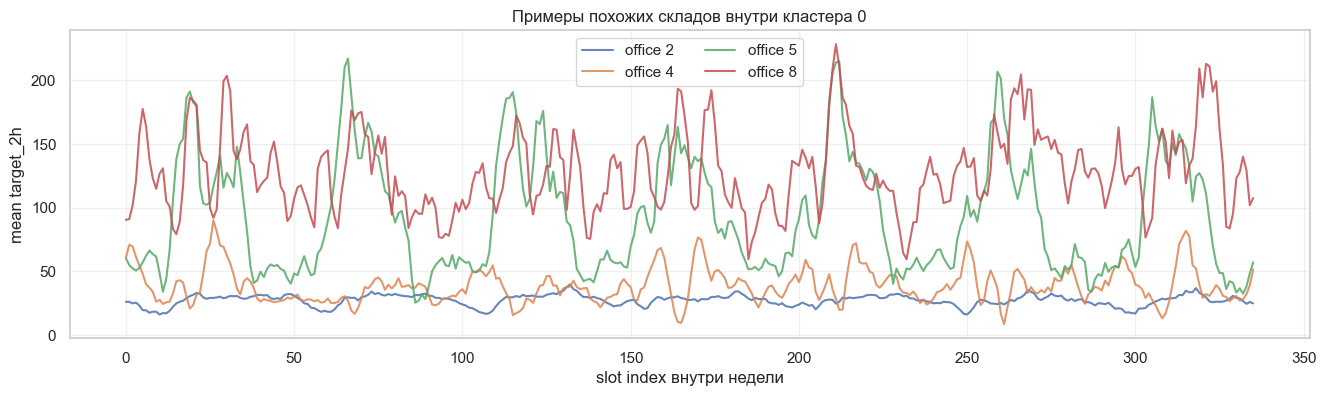

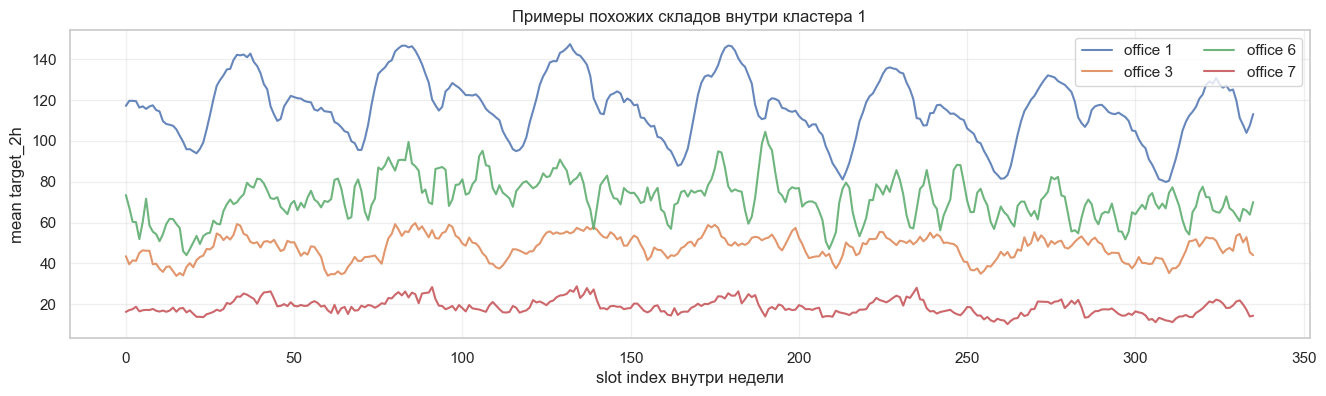

Top similar office pairs:


,office_1,office_2,corr
0,1,12,0.949886
1,12,22,0.896252
2,1,22,0.886786
3,22,27,0.875898
4,12,27,0.872039
5,1,27,0.867558
6,22,46,0.847164
7,10,22,0.837281
8,10,46,0.834761
9,1,46,0.820029


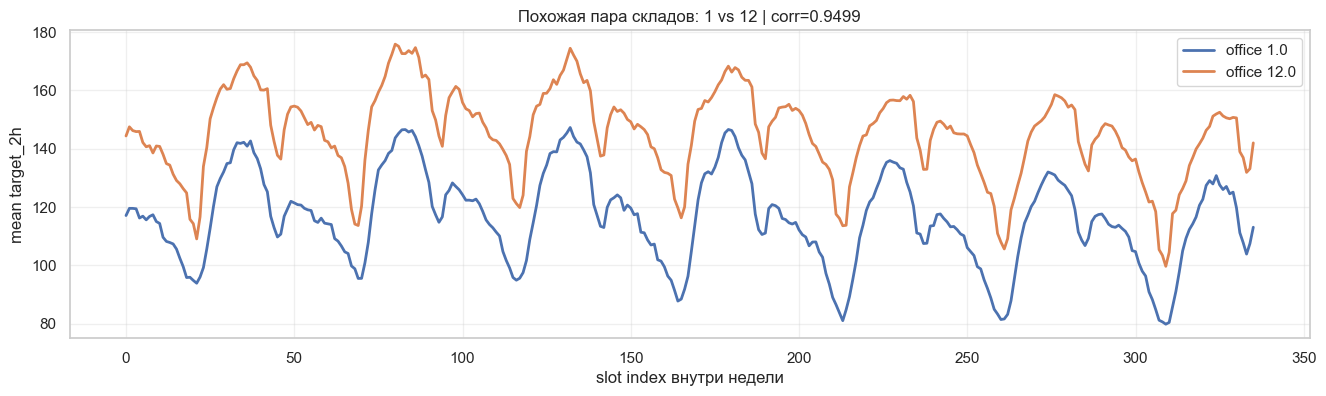

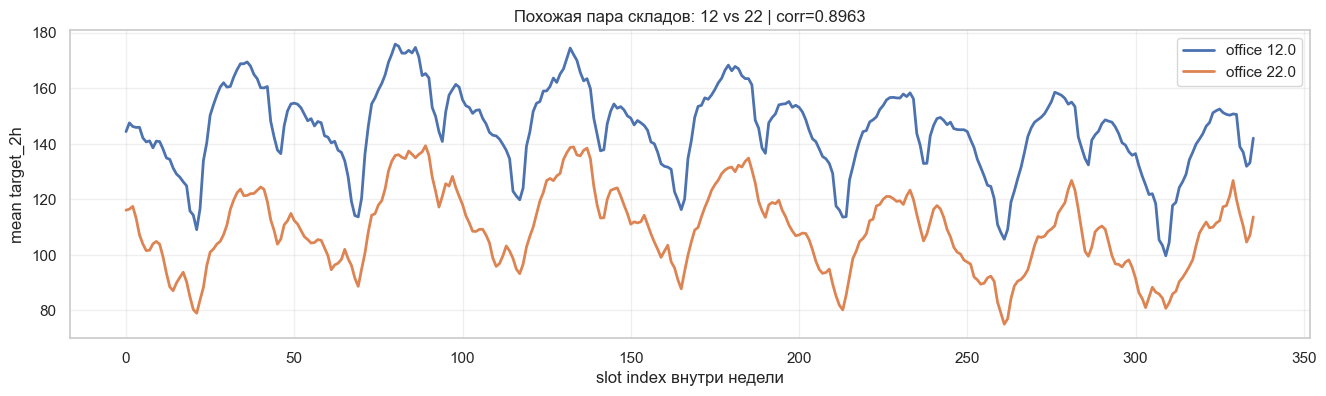

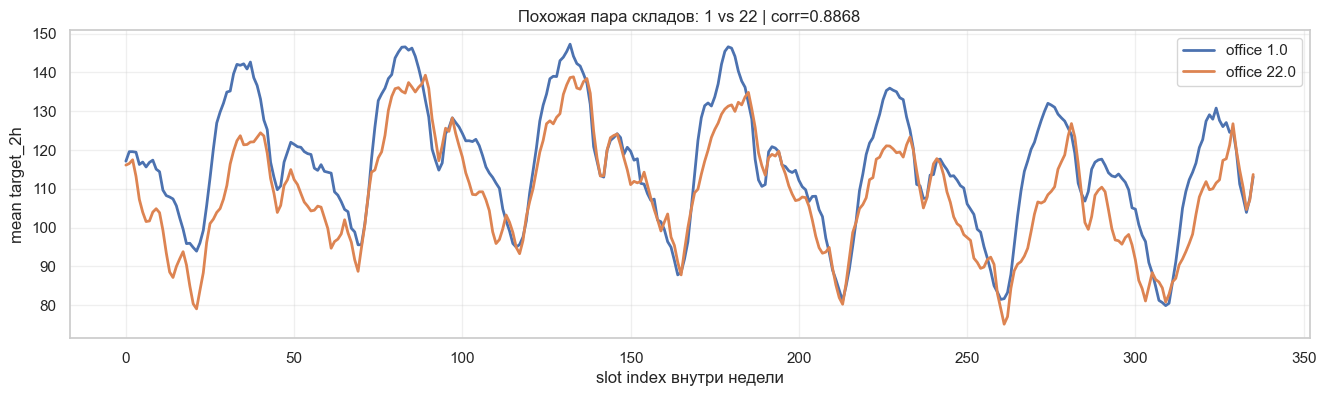

In [13]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- подготовка временных признаков для office-level анализа ---
train_office = train.copy()
train_office["dow"] = train_office["timestamp"].dt.dayofweek
train_office["hour"] = train_office["timestamp"].dt.hour
train_office["minute"] = train_office["timestamp"].dt.minute
train_office["date"] = train_office["timestamp"].dt.date

# 48 слотов внутри недели: здесь берем профиль по (dow, hour, minute)
office_slot_profile = (
    train_office
    .groupby(["office_from_id", "dow", "hour", "minute"], as_index=False)["target_2h"]
    .mean()
)

office_profile_wide = office_slot_profile.pivot_table(
    index="office_from_id",
    columns=["dow", "hour", "minute"],
    values="target_2h",
    fill_value=0.0
).sort_index(axis=1)

print("Office profile matrix shape:", office_profile_wide.shape)

# Нормализация профиля внутри каждого склада:
# хотим сравнивать форму тренда, а не только абсолютный уровень target
office_profile_norm = office_profile_wide.sub(office_profile_wide.mean(axis=1), axis=0)
office_profile_norm = office_profile_norm.div(
    office_profile_wide.std(axis=1).replace(0, 1.0), axis=0
).fillna(0.0)

# --- выбираем число кластеров по silhouette на небольшом диапазоне ---
candidate_k = list(range(2, min(8, len(office_profile_norm)) + 1))
scores = []

for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(office_profile_norm)
    score = silhouette_score(office_profile_norm, labels)
    scores.append((k, score))

silhouette_df = pd.DataFrame(scores, columns=["k", "silhouette"])
display(silhouette_df)

best_k = silhouette_df.sort_values("silhouette", ascending=False).iloc[0]["k"]
best_k = int(best_k)
print("Best k by silhouette:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
office_cluster_labels = kmeans.fit_predict(office_profile_norm)

office_clusters = pd.DataFrame({
    "office_from_id": office_profile_norm.index,
    "trend_cluster": office_cluster_labels
}).sort_values(["trend_cluster", "office_from_id"]).reset_index(drop=True)

display(office_clusters.head(20))

# --- средний профиль target по кластерам ---
office_with_cluster = train_office.merge(office_clusters, on="office_from_id", how="left", validate="many_to_one")

cluster_slot_mean = (
    office_with_cluster
    .groupby(["trend_cluster", "dow", "hour", "minute"], as_index=False)["target_2h"]
    .mean()
)

n_clusters = office_clusters["trend_cluster"].nunique()
fig, axes = plt.subplots(n_clusters, 1, figsize=(16, 4 * n_clusters), sharex=True)
if n_clusters == 1:
    axes = [axes]

for cl, ax in zip(sorted(office_clusters["trend_cluster"].unique()), axes):
    tmp = cluster_slot_mean[cluster_slot_mean["trend_cluster"] == cl].copy()
    tmp["slot_idx"] = tmp["dow"] * 48 + tmp["hour"] * 2 + (tmp["minute"] // 30)
    tmp = tmp.sort_values("slot_idx")
    ax.plot(tmp["slot_idx"], tmp["target_2h"], linewidth=2)
    ax.set_title(f"Средний недельный профиль target_2h для кластера {cl}")
    ax.set_ylabel("mean target_2h")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("slot index внутри недели (48 слотов на день)")
plt.tight_layout()
plt.show()

# --- несколько складов внутри каждого кластера ---
sample_offices = (
    office_clusters.groupby("trend_cluster", sort=True)
    .head(4)
    .sort_values(["trend_cluster", "office_from_id"])
)

sample_df = (
    train_office.merge(sample_offices, on="office_from_id", how="inner")
    .groupby(["trend_cluster", "office_from_id", "dow", "hour", "minute"], as_index=False)["target_2h"]
    .mean()
)
sample_df["slot_idx"] = sample_df["dow"] * 48 + sample_df["hour"] * 2 + (sample_df["minute"] // 30)

for cl in sorted(sample_df["trend_cluster"].unique()):
    plt.figure(figsize=(16, 4))
    tmp = sample_df[sample_df["trend_cluster"] == cl]
    for office_id, grp in tmp.groupby("office_from_id", sort=True):
        grp = grp.sort_values("slot_idx")
        plt.plot(grp["slot_idx"], grp["target_2h"], label=f"office {office_id}", alpha=0.85)
    plt.title(f"Примеры похожих складов внутри кластера {cl}")
    plt.xlabel("slot index внутри недели")
    plt.ylabel("mean target_2h")
    plt.legend(ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- самые похожие пары складов по корреляции профилей ---
office_corr = office_profile_norm.T.corr()
pairs = []
idx = office_corr.index.tolist()

for i in range(len(idx)):
    for j in range(i + 1, len(idx)):
        pairs.append((idx[i], idx[j], office_corr.iloc[i, j]))

top_pairs = (
    pd.DataFrame(pairs, columns=["office_1", "office_2", "corr"])
    .sort_values("corr", ascending=False)
    .reset_index(drop=True)
)

print("Top similar office pairs:")
display(top_pairs.head(10))

# Графики для топ-3 похожих пар
top3 = top_pairs.head(3)
for _, row in top3.iterrows():
    offices = [row["office_1"], row["office_2"]]
    plt.figure(figsize=(16, 4))
    for office_id in offices:
        grp = office_slot_profile[office_slot_profile["office_from_id"] == office_id].copy()
        grp["slot_idx"] = grp["dow"] * 48 + grp["hour"] * 2 + (grp["minute"] // 30)
        grp = grp.sort_values("slot_idx")
        plt.plot(grp["slot_idx"], grp["target_2h"], label=f"office {office_id}", linewidth=2)
    plt.title(f"Похожая пара складов: {int(row['office_1'])} vs {int(row['office_2'])} | corr={row['corr']:.4f}")
    plt.xlabel("slot index внутри недели")
    plt.ylabel("mean target_2h")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



### Выводы по блоку похожих складов

Что можно использовать дальше в модели:

- `trend_cluster` как категориальный признак склада;
- cluster-level статистики target и `status_*`;
- расстояние/корреляцию склада до центра кластера как дополнительный числовой признак;
- отдельные модели по кластерам складов, если профили различаются достаточно сильно.



## 12) Восстановление `status_*` для `test` из истории train

В `test` нет колонок `status_*`, но их можно **аппроксимировать историческими средними** из train.

Так как:
- `route_id -> office_from_id` отображается однозначно;
- временной шаг фиксирован (30 минут);
- тест идет сразу после train;

можно построить для каждого склада исторический профиль статусов по ключам:

1. `office_from_id + dow + hour + minute` — самый точный вариант;  
2. `office_from_id + dow + hour` — fallback;  
3. `office_from_id + hour + minute` — fallback без дня недели;  
4. `office_from_id` — глобальный fallback по складу.

Ниже создаются признаки статусов для `test` именно по этой схеме.


In [14]:

# --- route_id -> office_from_id ---
route_to_office = (
    train[["route_id", "office_from_id"]]
    .drop_duplicates()
    .sort_values(["route_id", "office_from_id"])
)

assert route_to_office["route_id"].nunique() == len(route_to_office), "route_id must map to exactly one office_from_id"

test_ext = test.merge(route_to_office, on="route_id", how="left", validate="many_to_one").copy()

status_cols = [c for c in train.columns if c.startswith("status_")]

# --- служебная таблица времени ---
train_status = train.copy()
train_status["dow"] = train_status["timestamp"].dt.dayofweek
train_status["hour"] = train_status["timestamp"].dt.hour
train_status["minute"] = train_status["timestamp"].dt.minute

test_ext["dow"] = test_ext["timestamp"].dt.dayofweek
test_ext["hour"] = test_ext["timestamp"].dt.hour
test_ext["minute"] = test_ext["timestamp"].dt.minute

# --- профили для иерархического восстановления ---
prof_exact = (
    train_status
    .groupby(["office_from_id", "dow", "hour", "minute"], as_index=False)[status_cols]
    .mean()
)

prof_dow_hour = (
    train_status
    .groupby(["office_from_id", "dow", "hour"], as_index=False)[status_cols]
    .mean()
)

prof_hour_min = (
    train_status
    .groupby(["office_from_id", "hour", "minute"], as_index=False)[status_cols]
    .mean()
)

prof_office = (
    train_status
    .groupby(["office_from_id"], as_index=False)[status_cols]
    .mean()
)

# --- последовательно мержим и заполняем пропуски ---
test_status_feat = test_ext.copy()

# 1) exact: office + dow + hour + minute
exact_cols = [f"{c}_exact" for c in status_cols]
tmp = prof_exact.rename(columns={c: f"{c}_exact" for c in status_cols})
test_status_feat = test_status_feat.merge(
    tmp, on=["office_from_id", "dow", "hour", "minute"], how="left"
)

# 2) office + dow + hour
dow_hour_cols = [f"{c}_dh" for c in status_cols]
tmp = prof_dow_hour.rename(columns={c: f"{c}_dh" for c in status_cols})
test_status_feat = test_status_feat.merge(
    tmp, on=["office_from_id", "dow", "hour"], how="left"
)

# 3) office + hour + minute
hour_min_cols = [f"{c}_hm" for c in status_cols]
tmp = prof_hour_min.rename(columns={c: f"{c}_hm" for c in status_cols})
test_status_feat = test_status_feat.merge(
    tmp, on=["office_from_id", "hour", "minute"], how="left"
)

# 4) office global
office_cols = [f"{c}_office" for c in status_cols]
tmp = prof_office.rename(columns={c: f"{c}_office" for c in status_cols})
test_status_feat = test_status_feat.merge(
    tmp, on=["office_from_id"], how="left"
)

for c in status_cols:
    test_status_feat[c] = (
        test_status_feat[f"{c}_exact"]
        .fillna(test_status_feat[f"{c}_dh"])
        .fillna(test_status_feat[f"{c}_hm"])
        .fillna(test_status_feat[f"{c}_office"])
    ).astype("float32")

# Оставляем компактную версию test со статусами
test_with_status = test_status_feat[["id", "route_id", "office_from_id", "timestamp"] + status_cols].copy()

print("test_with_status shape:", test_with_status.shape)
display(test_with_status.head())

na_report = test_with_status[status_cols].isna().mean().sort_values(ascending=False)
print("Share of NaN after hierarchical fill:")
display(na_report)

# Для контроля посмотрим распределения восстановленных статусов
status_compare = pd.DataFrame({
    "train_mean": train[status_cols].mean(),
    "test_restored_mean": test_with_status[status_cols].mean(),
    "train_std": train[status_cols].std(),
    "test_restored_std": test_with_status[status_cols].std(),
}).sort_index()

display(status_compare)


test_with_status shape: (10000, 12)


,id,route_id,office_from_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8
0,0,29,4,2025-05-30 11:00:00+00:00,1056.369019,298.535706,837.285706,178.976196,551.666687,556.964294,51.464287,6.000000
1,1,29,4,2025-05-30 11:30:00+00:00,1106.059570,328.607147,966.261902,231.095245,938.059509,1051.678589,249.642853,15.178572
2,2,29,4,2025-05-30 12:00:00+00:00,1135.500000,326.083344,1062.523804,218.619049,640.892883,605.797607,306.678558,7.785714
3,3,29,4,2025-05-30 12:30:00+00:00,1149.071411,320.047607,1045.178589,301.892853,992.821411,1065.309570,22.059525,13.761905
4,4,29,4,2025-05-30 13:00:00+00:00,1227.035767,333.238098,1120.916626,313.892853,1124.940430,1116.285767,1380.845215,3.404762


Share of NaN after hierarchical fill:


status_1    0.0
status_2    0.0
status_3    0.0
status_4    0.0
status_5    0.0
status_6    0.0
status_7    0.0
status_8    0.0
dtype: float64

,train_mean,test_restored_mean,train_std,test_restored_std
status_1,1310.748731,1676.194946,2501.866251,2300.751953
status_2,146.998607,188.928696,206.666088,187.524963
status_3,1278.569003,1559.735229,2310.502482,2127.520996
status_4,1102.996098,1236.751953,1740.374614,1535.989746
status_5,1555.774074,1613.160156,2194.728055,1739.170898
status_6,1555.737880,1583.098755,2255.212710,1700.142090
status_7,2243.071239,2156.003906,4913.773645,1902.901001
status_8,916.167541,862.797424,1872.031485,868.424194



### Как использовать восстановленные `status_*` в моделях

Теперь можно сделать 2 варианта:

1. **Простой**: оставить текущий baseline как есть, а блок `test_with_status` использовать только для EDA и последующих экспериментов.
2. **Усиленный**: включить:
   - `office_from_id`,
   - восстановленные `status_*`,
   - cluster-признак склада (`trend_cluster`)

   в табличную модель (`CatBoost`, `LightGBM`, `XGBoost`, `HistGBM`) и сравнить на rolling backtest.

Ниже — пример, как собрать train/test таблицы для такого эксперимента.


In [15]:

# --- train: добавляем time features + office-level cluster ---
train_model_ext = train.copy()
train_model_ext["hour"] = train_model_ext["timestamp"].dt.hour.astype("int16")
train_model_ext["dow"] = train_model_ext["timestamp"].dt.dayofweek.astype("int16")
train_model_ext["minute"] = train_model_ext["timestamp"].dt.minute.astype("int16")
train_model_ext["is_weekend"] = (train_model_ext["dow"] >= 5).astype("int8")
train_model_ext["hour_sin"] = np.sin(2 * np.pi * train_model_ext["hour"] / 24).astype("float32")
train_model_ext["hour_cos"] = np.cos(2 * np.pi * train_model_ext["hour"] / 24).astype("float32")
train_model_ext["dow_sin"] = np.sin(2 * np.pi * train_model_ext["dow"] / 7).astype("float32")
train_model_ext["dow_cos"] = np.cos(2 * np.pi * train_model_ext["dow"] / 7).astype("float32")

train_model_ext = train_model_ext.merge(office_clusters, on="office_from_id", how="left")

test_model_ext = test_with_status.copy()
test_model_ext["hour"] = test_model_ext["timestamp"].dt.hour.astype("int16")
test_model_ext["dow"] = test_model_ext["timestamp"].dt.dayofweek.astype("int16")
test_model_ext["minute"] = test_model_ext["timestamp"].dt.minute.astype("int16")
test_model_ext["is_weekend"] = (test_model_ext["dow"] >= 5).astype("int8")
test_model_ext["hour_sin"] = np.sin(2 * np.pi * test_model_ext["hour"] / 24).astype("float32")
test_model_ext["hour_cos"] = np.cos(2 * np.pi * test_model_ext["hour"] / 24).astype("float32")
test_model_ext["dow_sin"] = np.sin(2 * np.pi * test_model_ext["dow"] / 7).astype("float32")
test_model_ext["dow_cos"] = np.cos(2 * np.pi * test_model_ext["dow"] / 7).astype("float32")

test_model_ext = test_model_ext.merge(office_clusters, on="office_from_id", how="left")

print("train_model_ext:", train_model_ext.shape)
print("test_model_ext:", test_model_ext.shape)

display(train_model_ext.head())
display(test_model_ext.head())


train_model_ext: (4342000, 21)
test_model_ext: (10000, 21)


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,hour,dow,minute,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,trend_cluster
0,4,29,2025-03-01 00:00:00+00:00,3105,340,2160,484,4018,3462,0,0,27.0,0,5,0,1,0.000000,1.000000,-0.974928,-0.222521,0
1,4,29,2025-03-01 00:30:00+00:00,2813,388,2058,373,1363,1657,9380,0,27.0,0,5,30,1,0.000000,1.000000,-0.974928,-0.222521,0
2,4,29,2025-03-01 01:00:00+00:00,2465,293,2098,472,3195,3325,0,0,23.0,1,5,0,1,0.258819,0.965926,-0.974928,-0.222521,0
3,4,29,2025-03-01 01:30:00+00:00,1977,252,2351,310,3314,3243,0,0,37.0,1,5,30,1,0.258819,0.965926,-0.974928,-0.222521,0
4,4,29,2025-03-01 02:00:00+00:00,1585,206,2500,300,2130,1604,0,0,31.0,2,5,0,1,0.500000,0.866025,-0.974928,-0.222521,0


,id,route_id,office_from_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,hour,dow,minute,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,trend_cluster
0,0,29,4,2025-05-30 11:00:00+00:00,1056.369019,298.535706,837.285706,178.976196,551.666687,556.964294,51.464287,6.000000,11,4,0,0,2.588190e-01,-0.965926,-0.433884,-0.900969,0
1,1,29,4,2025-05-30 11:30:00+00:00,1106.059570,328.607147,966.261902,231.095245,938.059509,1051.678589,249.642853,15.178572,11,4,30,0,2.588190e-01,-0.965926,-0.433884,-0.900969,0
2,2,29,4,2025-05-30 12:00:00+00:00,1135.500000,326.083344,1062.523804,218.619049,640.892883,605.797607,306.678558,7.785714,12,4,0,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0
3,3,29,4,2025-05-30 12:30:00+00:00,1149.071411,320.047607,1045.178589,301.892853,992.821411,1065.309570,22.059525,13.761905,12,4,30,0,1.224647e-16,-1.000000,-0.433884,-0.900969,0
4,4,29,4,2025-05-30 13:00:00+00:00,1227.035767,333.238098,1120.916626,313.892853,1124.940430,1116.285767,1380.845215,3.404762,13,4,0,0,-2.588190e-01,-0.965926,-0.433884,-0.900969,0



## 13) Подходы к решению прогноза `target_2h` (5 вариантов)

Ниже — 5 осмысленных направлений, которые логично следуют из EDA и новых признаков.

### Вариант 1. Сильный табличный бустинг по лагам + календарю + восстановленным статусам
**Идея:** взять `CatBoost / LightGBM / XGBoost` и подать:
- лаги `target_2h`;
- rolling-статистики;
- календарные признаки;
- `office_from_id`, `route_id`;
- восстановленные `status_*` для test;
- `trend_cluster`.

**Почему может сработать:** данные очень регулярные, шаг фиксированный, история длинная, а бустинги хорошо учат нелинейные взаимодействия признаков.

---

### Вариант 2. Двухуровневая модель: global + local correction
**Идея:**  
- первая модель предсказывает общий паттерн по всем маршрутам;
- вторая модель дообучается на остатках:
  - либо по каждому складу,
  - либо по кластеру похожих складов,
  - либо по route-level статистикам.

**Почему может сработать:** в данных есть одновременно глобальная сезонность и локальная специфика отдельных складов/маршрутов.

---

### Вариант 3. Модели по кластерам похожих складов
**Идея:** использовать кластеризацию складов по форме тренда и обучать отдельную модель на каждый `trend_cluster`.

**Почему может сработать:** если склады реально имеют разные режимы работы, единая модель может усреднять слишком разные профили и терять качество.

---

### Вариант 4. Прямой multi-step прогноз вместо полностью рекурсивного
**Идея:** вместо одного одношагового регрессора сделать:
- 10 отдельных моделей по шагам горизонта, или
- одну модель с признаком `horizon_step`.

**Почему может сработать:** в backtest видно, что ошибка растет по мере удаления от начала горизонта; direct multi-step часто устойчивее, чем чистая рекурсия.

---

### Вариант 5. Гибрид: baseline временного профиля + ML на остатках
**Идея:**  
1. построить базовый прогноз как историческое среднее по:
   - `office_from_id + dow + hour + minute`,
   - или `route_id + dow + hour + minute`;  
2. обучить ML-модель предсказывать отклонение от этого базового профиля.

**Почему может сработать:** у ряда маршрутов большая часть сигнала — это повторяющийся временной шаблон, а модели проще предсказывать остаток, чем полный уровень target.

---

## Практический приоритет запуска экспериментов

Если идти по соотношению "сложность / ожидаемый выигрыш", я бы рекомендовал такой порядок:

1. **CatBoost/LightGBM + лаги + статусные признаки + office/cluster признаки**  
2. **Direct multi-step модель на 10 шагов**  
3. **Профильный baseline + ML на residual**  
4. **Отдельные модели по cluster/office**  
5. **Stacking global + local correction**

Это даст быстрый и логичный путь от текущего baseline к более сильному решению.
